In [1]:
import requests
import json
import time

API_URL = "http://localhost:4000/api/ask"


In [2]:
test_cases = [

    # Questions from CH1 - Work Orders
    { "question": "What are the two ways users can log into MaintStar EAMS v15?" },
    { "question": "What happens after clicking 'Submit' during login with MaintStar Security?" },
    { "question": "What is the difference between logging in with MaintStar Security and Single Sign-On (SSO)?" },
    { "question": "What are 'Workgroups' in MaintStar EAMS v15?" },
    { "question": "How do Workgroups differ from 'Modules' in earlier versions?" },
    { "question": "Can resources be shared between Workgroups? Give an example." },
    { "question": "What does the hamburger icon do on the Home Screen?" },
    { "question": "What is the function of the arrow in the upper right of the Home Screen?" },
    { "question": "Where can you find the Workgroup selector on the Home Screen?" },
    { "question": "What does the 'power' icon do?" },
    { "question": "What does the Work Order menu item include?" },
    { "question": "Which menu item would you use for creating requisitions?" },
    { "question": "Which menu item allows for advanced planning of resources and activities?" },
    { "question": "What are the two views available for Work Orders?" },
    { "question": "How can you switch between Grid view and Card view?" },
    { "question": "Name three tabs available on a Work Order screen and their purpose." },
    { "question": "What is stored in the LEM tab?" },
    { "question": "What does the 'Issued' field represent on a Work Order?" },
    { "question": "What are 'Activity Codes' used for?" },
    { "question": "What is the difference between 'Assigned To' and 'Crew Leader' in a Work Order?" },
    { "question": "Can multiple assets be added to a single Work Order?" },
    { "question": "How can assets be added to a Work Order?" },
    { "question": "What can tasks assigned to assets include?" },
    { "question": "What does LEM stand for in a Work Order?" },
    { "question": "List at least three types of LEM entries you can add." },
    { "question": "What is a 'Management Unit' in a LEM line, and where does it appear?" },
    { "question": "Where can you view or upload attachments to a Work Order?" },
    { "question": "What does the Asset History tab show?" },
    { "question": "What information is stored in the Requestor tab?" },
    { "question": "What does the Job Site tab allow you to do?" },
    { "question": "How can you display the map in EAMS v15?" },
    { "question": "What is the Map Measurement Tool used for?" },
    { "question": "How do you use the Quick Look Up feature?" },
    { "question": "What replaces the F10 lookup in version 15?" },
    { "question": "What do you click to create a new Work Order?" },
    { "question": "How do you close a Work Order?" },
    { "question": "What happens when you click the printer icon on a Work Order?" },
    { "question": "What do you need to do to email a Work Order?" },

    # Questions from CH1_3 - CM Templates
    { "question": "What is the main difference between a PM Template and a CM Template?" },
    { "question": "Do CM Templates have a frequency or schedule?" },
    { "question": "Where are CM Templates created and stored in MaintStar?" },
    { "question": "List at least four elements that can be configured in a CM Template." },
    { "question": "Where can you place work instructions in a CM Template?" },
    { "question": "Can LEM data be added to a CM Template?" },
    { "question": "What is the purpose of the Asset Type tab in a CM Template?" },
    { "question": "What happens if no asset type is associated with a CM Template?" },
    { "question": "What are the two ways to create a Work Order from a CM Template?" },
    { "question": "Describe how to create a Work Order from the Asset screen using a CM Template." },
    { "question": "What steps are needed to create a Work Order from the Work Order screen using a CM Template?" },
    { "question": "Can you edit a Work Order after it is created from a CM Template?" },
    { "question": "What is the benefit of using a CM Template over duplicating a previous Work Order?" },
    { "question": "Can you store multiple CM Templates in MaintStar?" },
    { "question": "Which fields can be pre-filled in a CM Template to reduce repetitive data entry?" },
    { "question": "How are estimated hours and costs added to a CM Template?" },
    { "question": "Can attachments and checklists be included in a CM Template?" },
    { "question": "What happens if you associate specific asset types with a CM Template?" },
    { "question": "How do you make a CM Template available to all asset types?" },
    { "question": "What does the green 'New CM Work Order' button do when starting from the Asset screen?" },
    { "question": "What does clicking 'More' do when creating a new Work Order from the Work Order screen?" },
    { "question": "When starting from a CM Template, can field values be modified after the Work Order is created?" },
    { "question": "Where in the interface do you go to access the CM Template section?" },
    { "question": "What section of the menu stores the CM Templates?" },

    # Questions from CH2 - Preventative Maintenance
    { "question": "What is the purpose of a Preventative Maintenance (PM) template?" },
    { "question": "How does a PM template differ from a CM template?" },
    { "question": "What types of frequency can PMs be based on?" },
    { "question": "What is the difference between fixed and floating PM schedules?" },
    { "question": "What is the role of the 'Last Due Date' in a PM schedule?" },
    { "question": "Where can you access the PM menu in MaintStar?" },
    { "question": "What sections are found in the PM Template screen?" },
    { "question": "How do you create a new PM template?" },
    { "question": "What are the two ways to enter work instructions in a PM template?" },
    { "question": "How do you set the calendar-based frequency for a PM?" },
    { "question": "How can meter readings be used in PM scheduling?" },
    { "question": "What happens if a floating schedule PM is not closed on time?" },
    { "question": "What does checking the 'Create next PM even if current is open' box do?" },
    { "question": "What options are available on the LEM tab of a PM template?" },
    { "question": "What is the difference between 'Add Row' and 'Add Task' on the task tab?" },
    { "question": "What does N1 mean in task nesting for PMs?" },
    { "question": "What problem does nesting solve in PM scheduling?" },
    { "question": "How does version 15 support nesting with tasks?" },
    { "question": "How do you assign assets and schedules to a PM template?" },
    { "question": "What is the function of the 'Add Group' button when assigning assets?" },
    { "question": "What are the three ways to issue PM Work Orders?" },
    { "question": "How does the 'Create WO from PM Schedule Screen' method work?" },
    { "question": "What is the purpose of the Batch Issue Setup screen?" },
    { "question": "What options can be configured when setting up a batch schedule?" },
    { "question": "What is the PM Log used for?" },
    { "question": "What types of reports are available in the PM Reports section?" },
    { "question": "What is a PM template?" },
    { "question": "How do I schedule preventative maintenance?" },
    { "question": "What is frequency in a PM?" },
    { "question": "Can PMs be triggered by time and usage together?" },
    { "question": "How are work orders created from PMs?" },

    # Questions from CH3 - Work Request and Portal
    { "question": "What are the three types of users in the MaintStar Work Request system?" },
    { "question": "Can external users submit requests anonymously in MaintStar?" },
    { "question": "What is the purpose of the Work Request module?" },
    { "question": "What are the main tabs in the Work Request screen?" },
    { "question": "What does the 'Create WO' tab do in a Work Request?" },
    { "question": "What is stored in the 'Customers' section of the Work Request menu?" },
    { "question": "How does the 'Duplicate' feature help with Work Requests?" },
    { "question": "What can be configured in the WR Control tab?" },
    { "question": "How does the WR Pattern field affect request IDs?" },
    { "question": "What is the difference between the three operation levels in the Work Request module?" },
    { "question": "How does the system use the 'Operation', 'Issue', and 'Issue Detail' hierarchy?" },
    { "question": "What controls whether a Work Request category is visible to the public portal?" },
    { "question": "What is the purpose of user 'Groups' in the Work Request configuration?" },
    { "question": "How can groups control which operations are visible to different types of users?" },
    { "question": "What does the 'Notifications' tab in WR Settings configure?" },
    { "question": "What is the MaintStar Portal designed for?" },
    { "question": "Can an organization have more than one portal in MaintStar?" },
    { "question": "What are the four internal system statuses for Work Requests?" },
    { "question": "What happens when a Work Order is created from a Work Request?" },
    { "question": "What fields are available in the Customer table?" },
    { "question": "How does the system notify customers of Work Request status updates?" },
    { "question": "What actions can be taken from the Portal entry screen?" },
    { "question": "How does the Portal adapt to different devices like phones or tablets?" },
    { "question": "What information can be attached to a Work Request from the portal?" },
    { "question": "How does location data get associated with a request in the portal?" },
    { "question": "What are the filter options available in the request list on the Portal?" },
    { "question": "What does the 'Add a new request' button do in the Portal?" },
    { "question": "How is the red star used in the request entry screen?" },
    { "question": "What happens after submitting a Work Request through the portal?" },

    # Questions from CH4 - Notifications

      { "question": "What are the different types of notifications supported by MaintStar?" },
      { "question": "When can notifications be triggered for Work Orders in MaintStar?" },
      { "question": "Where can users check their internal notifications?" },
      { "question": "What is required for a user to receive email notifications in MaintStar?" },
      { "question": "What is required for a user to receive SMS text notifications in MaintStar?" },
      { "question": "How can an admin configure the system to automatically prepend a phone country code for texting?" },
      { "question": "What settings can users control in Home -> My Preferences related to notifications?" },
      { "question": "How can an admin restrict a user's ability to change their own notification preferences?" },
      { "question": "Where are Work Order notifications configured system-wide?" },
      { "question": "What is the difference between 'Notification by Role' and 'Notification by User'?" },
      { "question": "Can you configure granular action-based notification preferences, such as choosing 'this but not that'?" },
      { "question": "What are Notification Templates used for in MaintStar?" },
      { "question": "Where can you view or create custom notification templates?" },
      { "question": "What are special variables in notification templates, and how are they used?" },
      { "question": "What determines where a custom notification template can be used in the system?" },
      { "question": "Which tab controls notifications for specific Issues and Operations in Work Requests?" },
      { "question": "Where do you configure which internal users are notified when certain WR Operations or Issues are selected?" },
      { "question": "What triggers the 'Notify when Operation selected' notification for a Work Request?" },
      { "question": "When is the 'Notify when WR is assigned' notification triggered?" },
      { "question": "What does the 'Notify supervisor when WR is assigned' option do?" },
      { "question": "Can Work Request notifications be customized by user group?" },
      { "question": "What user field is used to notify the requester in a Work Request?" },
      { "question": "What must exist for any notification setting to function properly?" },
      { "question": "Can different messages be created for Email and SMS notifications in a template?" },
      { "question": "Where can you find the list of available fields to use in a notification template?" },

    # Questions from CH5 - Assets

      { "question": "What is an asset in MaintStar EAMS?" },
      { "question": "What is the difference between an Asset Type and an Asset Group?" },
      { "question": "What is a Bill Rate in the context of assets?" },
      { "question": "How does MaintStar support asset customization?" },
      { "question": "What does the Condition Index track for an asset?" },
      { "question": "Where can you find the asset’s full Work Order history?" },
      { "question": "What is stored in the Asset Parts section?" },
      { "question": "What kind of alerts can Asset Notes and Warnings provide?" },
      { "question": "What is the purpose of assigning a Meter Type to an asset?" },
      { "question": "What are COF and POF used for in asset management?" },
      { "question": "How is criticality calculated in MaintStar?" },
      { "question": "How can assets be grouped for easier scheduling?" },
      { "question": "Where do you create a new Asset Type in the UI?" },
      { "question": "What happens if you try to use the same Asset ID in the same Asset Type?" },
      { "question": "Can Asset IDs be duplicated across different Asset Types?" },
      { "question": "What fields are commonly included in an Asset's details page?" },
      { "question": "What does it mean when an asset is 'Active – In for Repair'?" },
      { "question": "How are attachments used in the asset module?" },
      { "question": "What tab do you use to manually add a part to an asset?" },
      { "question": "What steps are needed to update a meter reading for an asset?" },
      { "question": "Why does MaintStar use a scale instead of zero for probability of failure?" },
      { "question": "Where can you find a cost summary of all Work Orders tied to an asset?" },
      { "question": "What are the ways to assign assets to Work Orders?" },
      { "question": "How do you search for an asset in MaintStar?" },
      { "question": "What are two examples of standard Asset Reports?" },
      { "question": "Can users save their custom asset filter searches?" },
      { "question": "How do you duplicate an asset in MaintStar?" },
      { "question": "What must be unique when duplicating an asset?" },
      { "question": "What is the recommended action for assets that are no longer in use?" },
      { "question": "When should you delete an asset instead of deactivating it?" },

    # Questions from CH5_2 - Asset Assessments

      { "question": "What must be configured before an Asset can be assessed in MaintStar?" },
      { "question": "What is the difference between a Condition Index and a Condition Rating?" },
      { "question": "What is an example of a numeric Condition Index scale?" },
      { "question": "What is an example of a letter-based Condition Rating scale?" },
      { "question": "Can different Asset Types use different Condition Indexes?" },
      { "question": "Where do you go to set up a new Condition Index?" },
      { "question": "What are the required fields when adding a new Condition Index?" },
      { "question": "Where do you set the upper and lower boundaries for a rating scale?" },
      { "question": "How do you associate a Condition Rating to a Condition Index?" },
      { "question": "Why is it important to assign a default Condition Index to an Asset Type?" },
      { "question": "What happens if you assign multiple Condition Indexes to an Asset Type but don’t select a default?" },
      { "question": "What user permissions are needed to set up Condition Indexes and Ratings?" },
      { "question": "How do you begin recording an Assessment for an Asset in MaintStar?" },
      { "question": "What tab in the Asset record allows you to add Assessments?" },
      { "question": "What fields can be recorded when entering an Asset Assessment?" },
      { "question": "What is the purpose of the 'Assessed Value' field in an Asset Assessment?" },
      { "question": "What is the difference between 'Assessed Value' and 'Replacement Cost'?" },
      { "question": "What field in an assessment captures how many years the asset is expected to last?" },
      { "question": "Where do you set 'Expected Life in Years' for an asset?" },
      { "question": "How can historic assessment data be accessed?" },
      { "question": "How can you analyze multiple Asset Assessments at once?" },
      { "question": "Where do you create queries for assessing condition trends across many assets?" },
      { "question": "What table should be selected when creating a query for Asset Assessments?" },
      { "question": "What fields are recommended in a custom query for Asset Assessments?" },
      { "question": "How can adding Install Date and Original Value improve assessment analysis?" },
      { "question": "What does MaintStar recommend for deeper asset analysis beyond ratings?" },
      { "question": "Why is it helpful to track Observed Issues in an Asset Assessment?" },
      { "question": "Can you track Remaining Life and Expected Life separately?" },
      { "question": "What setup steps must be completed before assessments will appear in reports or queries?" },
      { "question": "How can assessment data support budget and capital planning?" },
      { "question": "What happens if no assessment has ever been recorded for an asset?" },
      { "question": "Can you assign multiple assessments to the same asset over time?" },
      { "question": "How does MaintStar recommend using assessments for replacement decisions?" },
      { "question": "What tools does MaintStar provide to track deterioration or asset aging over time?" },
      { "question": "What types of assets might benefit from numeric vs. categorical condition ratings?" },

    # Questions from CH5_3 - Asset Acquisitions

      { "question": "What is the purpose of the Asset Acquisition tool in MaintStar?" },
      { "question": "How does the Acquisition tool support tracking an asset’s full lifecycle?" },
      { "question": "What kinds of assets are commonly entered using the Acquisition tool?" },
      { "question": "When is the Acquisition tool especially helpful?" },
      { "question": "Where can the Asset Acquisition tool be found in MaintStar?" },
      { "question": "What kind of information is stored on the Acquisition Record 'Details' page?" },
      { "question": "What is the purpose of the 'Bids' tab in an Acquisition Record?" },
      { "question": "What is the 'Asset Birth Certificate' tab used for?" },
      { "question": "How can attachments be added to an Acquisition Record?" },
      { "question": "How do you begin creating a new Acquisition Record?" },
      { "question": "Is a lot of required information needed to create a new Acquisition Record?" },
      { "question": "What two options are available to associate an asset to an Acquisition Record?" },
      { "question": "How do you add an existing asset to an Acquisition Record?" },
      { "question": "What is the function of the 'Asset Lookup' tool?" },
      { "question": "How do you create a new asset directly from the Acquisition screen?" },
      { "question": "What dialog appears when you create a new asset from the Acquisition screen?" },
      { "question": "What basic fields are needed when creating a new asset from an Acquisition Record?" },
      { "question": "Where is the asset added after it's created through the Acquisition screen?" },
      { "question": "What page allows you to enter data that will be transferred to the Asset record?" },
      { "question": "Can the Acquisition-to-Asset data transfer happen multiple times for the same asset?" },
      { "question": "What fields can be transferred from the Acquisition Record to the Asset record?" },
      { "question": "What must be done after entering acquisition data to ensure it updates the asset?" },
      { "question": "What action transfers acquisition data to the asset record?" },
      { "question": "What warning message appears before transferring data from Acquisition to Asset?" },
      { "question": "What happens after data is transferred from the Acquisition Record to the Asset?" },
      { "question": "After transfer, where must future updates be made: the Acquisition Record or the Asset?" },
      { "question": "Can multiple assets be added to a single Acquisition Record?" },
      { "question": "Why is it called an 'Asset Birth Certificate' in the Acquisition module?" },
      { "question": "How does using the Acquisition tool simplify data entry compared to manual asset creation?" },
      { "question": "Can contracts and invoices be attached to Acquisition Records?" },

    # Questions from CH5_4 - Asset Disposals

      { "question": "What is the purpose of the Asset Disposal tool in MaintStar?" },
      { "question": "How does the Disposal tool support asset lifecycle tracking?" },
      { "question": "Where can the Asset Disposal tool be found in the MaintStar menu?" },
      { "question": "What type of assets is the Disposal tool especially helpful for?" },
      { "question": "What must be completed before an asset can be marked as 'Done' in a Disposal record?" },
      { "question": "What happens to the asset status when a Disposal record is marked as 'Done'?" },
      { "question": "Does MaintStar delete assets when they are disposed?" },
      { "question": "What are the required fields when creating a Disposal record?" },
      { "question": "What optional fields can be filled out in a Disposal record?" },
      { "question": "What is the function of the Warnings tab in the Asset Disposal screen?" },
      { "question": "What are the three types of warnings that prevent a Disposal from being completed?" },
      { "question": "What happens if you try to finalize a disposal before clearing all warnings?" },
      { "question": "How do you remediate an open warning in a Disposal record?" },
      { "question": "Can you attach supporting documents to a Disposal record?" },
      { "question": "How can you track the condition of an asset being disposed?" },
      { "question": "What is the 'Recommended Method of Disposal' field used for?" },
      { "question": "What message is shown when an asset is successfully marked as 'Done'?" },
      { "question": "How do you reactivate an asset that has been marked inactive?" },
      { "question": "Where do you go to find Inactive assets in order to reactivate them?" },
      { "question": "What step is required to reactivate an asset in the asset list?" },
      { "question": "Why might a system administrator choose to use the Disposal tool over manual deactivation?" },
      { "question": "Can you complete a Disposal process for multiple assets at once?" },
      { "question": "Is it possible to undo the disposal of an asset in MaintStar?" },
      { "question": "What does the Disposal tool provide that a manual asset status change does not?" },
      { "question": "What types of documentation might you attach to a Disposal record?" },

    # Questions from CH5_5 - Asset Deficiencies

      { "question": "What is the purpose of the Asset Deficiencies module in MaintStar?" },
      { "question": "Is the Asset Deficiencies module optional or included by default?" },
      { "question": "What kind of assets are typically tracked using the Asset Deficiencies module?" },
      { "question": "How does MaintStar's deficiency tracking differ from using third-party tools?" },
      { "question": "What are some required setup steps before using the Asset Deficiencies module?" },
      { "question": "What is a Deficiency Type, and how is it configured?" },
      { "question": "What must be configured at the Asset Type level before recording a deficiency?" },
      { "question": "Where do you go to create a new Deficiency Asset Type?" },
      { "question": "What geometry types can be assigned to a Deficiency Asset Type?" },
      { "question": "Where do you configure Activity Codes for classifying Deficiencies?" },
      { "question": "What permissions are required to access the Setup > Tables menu?" },
      { "question": "How does GIS integration enhance the Deficiency module?" },
      { "question": "Can deficiencies be displayed and updated on a GIS map?" },
      { "question": "What is the purpose of the Deficiency Marker (black pin) on the map?" },
      { "question": "What fields can be entered when recording a Deficiency from the map?" },
      { "question": "What is the purpose of the 'Create Asset' button when recording a deficiency?" },
      { "question": "What are the two ways to create Work Orders from recorded Deficiencies?" },
      { "question": "How do you create a Work Order from a Deficiency Asset directly?" },
      { "question": "How do you create a Work Order from the map view?" },
      { "question": "What is the selection 'cart' used for during map-based Work Order creation?" },
      { "question": "How does the Map Filter tool help narrow down which Deficiencies need Work Orders?" },
      { "question": "What is the process to filter map data by Deficiency Type using GIS?" },
      { "question": "What steps are needed to run a filtered GIS query to select specific types of Deficiencies?" },
      { "question": "What happens once a Work Order is successfully created from the map or asset?" },
      { "question": "Can multiple Deficiencies be selected at once to create Work Orders?" },
      { "question": "How can the Deficiency module help with capital planning and inspection workflows?" },
      { "question": "What roles in an organization might typically record Asset Deficiencies?" },
      { "question": "How can inspectors and code enforcement officers use the Asset Deficiencies module?" },
      { "question": "What data is transferred from the Deficiency asset into the Work Order?" },
      { "question": "What is the benefit of having Deficiencies show on GIS maps as they are updated?" },

    # Questions from CH6 - Mobile Work Order

      { "question": "What is MaintStar Mobile and what devices is it compatible with?" },
      { "question": "Why might someone prefer a tablet over a phone for using MaintStar Mobile?" },
      { "question": "How does MaintStar Mobile support offline usage?" },
      { "question": "What GIS features does MaintStar Mobile provide?" },
      { "question": "What types of information can be added to a mobile work order in the field?" },
      { "question": "How does MaintStar Mobile integrate with a device’s camera?" },
      { "question": "What should you do if your device capitalizes the first letter of your password during login?" },
      { "question": "What are 'profiles' when logging into MaintStar Mobile?" },
      { "question": "What does the 'hamburger menu' in the top left corner do?" },
      { "question": "What information is displayed in the Main Menu?" },
      { "question": "How can assets be added to a work order from the GIS map?" },
      { "question": "What does a red wrench icon on the map signify?" },
      { "question": "How does MaintStar Mobile indicate that an asset is 'done'?" },
      { "question": "In what fields must your ID be listed to have work orders loaded automatically?" },
      { "question": "What are the differences between condensed and expanded work order list views?" },
      { "question": "What are the two main functions of the filter in the work order list?" },
      { "question": "What grouping options are available for work orders?" },
      { "question": "How can you attach a new photo to a work order using your mobile device?" },
      { "question": "What icon indicates there is an attachment on a work order?" },
      { "question": "What information is typically entered in the header section of a new work order?" },
      { "question": "What is the purpose of the 'Request Info' tab in a work order?" },
      { "question": "What does L.E.M. stand for?" },
      { "question": "What are the two display options for L.E.M. entries in Mobile Work Order?" },
      { "question": "How is adding a new LEM entry different when using full-screen entry versus grid view?" },
      { "question": "What are predefined tasks, and how do they function in Mobile Work Order?" },
      { "question": "What happens when all tasks for an asset are marked as done?" },
      { "question": "How can a user close a work order from their device?" },
      { "question": "What happens if closing conditions (such as part issuance) are not met?" },
      { "question": "How can administrators create customized Mobile Work Order screens?" },
      { "question": "How is a custom screen associated with a specific Work Order Type?" },

    # Questions from CH7 - KPI Dashboards

      { "question": "What is the KPI Dashboard in MaintStar used for?" },
      { "question": "Is a separate license required to use the KPI Dashboard?" },
      { "question": "Where can you check if the KPI-DASHBD right is assigned to a user?" },
      { "question": "How are KPI Dashboards shared or filtered for users?" },
      { "question": "What happens if a dashboard is shared with 'Read' rights?" },
      { "question": "Can MaintStar KPI Dashboards connect to tools like PowerBI or Tableau?" },
      { "question": "What chart types are available in the KPI Dashboard?" },
      { "question": "What does the Column Setup section define in a KPI dashboard?" },
      { "question": "What is the function of Number Boxes in a dashboard?" },
      { "question": "What is the use of Filters in KPI Dashboards?" },
      { "question": "What are the 7 basic steps to configure a KPI Dashboard?" },
      { "question": "How can a user add a chart or a filter from scratch in the dashboard?" },
      { "question": "How can dashboards be renamed, shared, or hidden?" },
      { "question": "What is the purpose of the dataset setup stage in dashboards?" },
      { "question": "Can users write custom SQL queries for dashboards?" },
      { "question": "How can multiple datasets be used in a single dashboard?" },
      { "question": "What happens when the 'Limit data to 4000 records' checkbox is enabled?" },
      { "question": "What kinds of filters can be applied to a dashboard?" },
      { "question": "How can filters be linked to specific charts?" },
      { "question": "What is the function of the Z column in line and bar charts?" },
      { "question": "How can chart types be changed during dashboard configuration?" },
      { "question": "What customization options exist for pie charts?" },
      { "question": "How do you group multiple charts in one block?" },
      { "question": "What options are available for gauge chart configuration?" },
      { "question": "What display settings are available for line charts?" },
      { "question": "What options are available for sorting bars in a bar chart?" },
      { "question": "How can a user configure totals and subtotals in a grid?" },
      { "question": "How does MaintStar automatically show map markers in the grid?" },
      { "question": "What columns trigger hyperlinks to work orders and assets in a grid?" },
      { "question": "How can users export data from a KPI dashboard?" },
      { "question": "How can you print a KPI dashboard?" },
      { "question": "What is dashboard duplication used for?" },
      { "question": "What are the steps to duplicate a dashboard?" },
      { "question": "How can users revert to an earlier version of a dashboard?" },

    # Questions from CH8.2 - Inventory ABC Cycle Counts

      { "question": "What is the ABC method in inventory cycle counting?" },
      { "question": "How does cycle counting differ from annual inventory counts?" },
      { "question": "What is required to use cycle counts in MaintStar?" },
      { "question": "What types of items typically fall under the A category?" },
      { "question": "How often are B category items usually counted?" },
      { "question": "What defines a C category item in an ABC cycle count?" },
      { "question": "What are the key steps in the cycle count process?" },
      { "question": "What is the purpose of tracking variance causes during a cycle count?" },
      { "question": "How can cycle counting improve inventory accuracy over time?" },
      { "question": "What does the 'To %' field represent in ABC setup?" },
      { "question": "How does MaintStar determine ABC class assignments?" },
      { "question": "Where is the ABC Cycle Count module located in MaintStar?" },
      { "question": "How can you confirm ABC class assignment for a specific part?" },
      { "question": "How can organizations customize ABC assignments by warehouse?" },
      { "question": "What filters can be applied during ABC Code Update to refine results?" },
      { "question": "What are Counting Sheets used for in the ABC Cycle Count process?" },
      { "question": "How can users customize Counting Sheets in MaintStar?" },
      { "question": "What is the Adjustment Sheet used for?" },
      { "question": "What steps are needed to perform an inventory adjustment?" },
      { "question": "What happens when the Overwrite box is selected and saved in an adjustment?" },
      { "question": "Why is it important to use the Adjustment Sheet instead of manual changes?" },
      { "question": "Can ABC assignments be updated based on transaction history filters?" },
      { "question": "What is the benefit of filtering ABC updates to a specific warehouse and time period?" },
      { "question": "How do you initiate the ABC Class Update in MaintStar?" },
      { "question": "Where can you find the ABC Code field for a part in the Inventory Summary?" },

    # Questions from CH9 - Asset Lifecycle Module

      { "question": "What is the Asset Lifecycle Module in MaintStar?" },
      { "question": "What tools are included in the Asset Lifecycle Module?" },
      { "question": "How does the Rating Wizard determine asset ratings?" },
      { "question": "What is the purpose of the COF Setup tool?" },
      { "question": "How is the Probability of Failure (POF) calculated?" },
      { "question": "What is Criticality and how is it calculated in MaintStar?" },
      { "question": "How can Capital Planning help with asset replacement scheduling?" },
      { "question": "What factors affect an asset’s lifecycle?" },
      { "question": "How do you set End of Life (EOL) age for an asset type?" },
      { "question": "Where do you input the install date for an asset?" },
      { "question": "How is EOL cost percentage determined?" },
      { "question": "What is the purpose of original and replacement cost fields?" },
      { "question": "How do you set up meters for asset types?" },
      { "question": "How are condition indexes configured and used?" },
      { "question": "What is an asset assessment and what information does it record?" },
      { "question": "What are the benefits of using asset ratings and assessments?" },
      { "question": "What are the steps to use the Asset Rating Wizard?" },
      { "question": "What happens when you click 'Apply' in the Rating Wizard?" },
      { "question": "How does redundancy affect criticality scores?" },
      { "question": "How are COF values manually set for assets?" },
      { "question": "What are the steps to run the POF Wizard?" },
      { "question": "How do you calculate and apply Criticality scores?" },
      { "question": "Can COF, POF, and Criticality be set manually?" },
      { "question": "What inputs are used for the Capital Planning tool?" },
      { "question": "How do you run Capital Planning replacement schedules?" },
      { "question": "What reports are available in the AL Reports module?" },
      { "question": "What does the Risk Matrix report show?" },
      { "question": "What does the End of Life report summarize?" },
      { "question": "What are the benefits of using KPIs and queries in MaintStar?" },

    # Questions from CH9_3 - Work Planning Module

      { "question": "What is the Asset Lifecycle Module in MaintStar?" },
      { "question": "What tools are included in the Asset Lifecycle Module?" },
      { "question": "How does the Rating Wizard determine asset ratings?" },
      { "question": "What is the purpose of the COF Setup tool?" },
      { "question": "How is the Probability of Failure (POF) calculated?" },
      { "question": "What is Criticality and how is it calculated in MaintStar?" },
      { "question": "How can Capital Planning help with asset replacement scheduling?" },
      { "question": "What factors affect an asset’s lifecycle?" },
      { "question": "How do you set End of Life (EOL) age for an asset type?" },
      { "question": "Where do you input the install date for an asset?" },
      { "question": "How is EOL cost percentage determined?" },
      { "question": "What is the purpose of original and replacement cost fields?" },
      { "question": "How do you set up meters for asset types?" },
      { "question": "How are condition indexes configured and used?" },
      { "question": "What is an asset assessment and what information does it record?" },
      { "question": "What are the benefits of using asset ratings and assessments?" },
      { "question": "What are the steps to use the Asset Rating Wizard?" },
      { "question": "What happens when you click 'Apply' in the Rating Wizard?" },
      { "question": "How does redundancy affect criticality scores?" },
      { "question": "How are COF values manually set for assets?" },
      { "question": "What are the steps to run the POF Wizard?" },
      { "question": "How do you calculate and apply Criticality scores?" },
      { "question": "Can COF, POF, and Criticality be set manually?" },
      { "question": "What inputs are used for the Capital Planning tool?" },
      { "question": "How do you run Capital Planning replacement schedules?" },
      { "question": "What reports are available in the AL Reports module?" },
      { "question": "What does the Risk Matrix report show?" },
      { "question": "What does the End of Life report summarize?" },
      { "question": "What are the benefits of using KPIs and queries in MaintStar?" },
      { "question": "What tools are included in the Asset Lifecycle Module?" },
      { "question": "How does the Rating Wizard determine asset ratings?" },
      { "question": "What is the Consequence of Failure (COF) Setup tool used for?" },
      { "question": "How is the Probability of Failure (POF) score calculated in MaintStar?" },
      { "question": "How is asset criticality calculated in MaintStar?" },
      { "question": "What does the Capital Planning tool allow organizations to do?" },
      { "question": "How are End of Life (EOL) Age settings configured in MaintStar?" },
      { "question": "Where is the Install Date set for an asset in MaintStar?" },
      { "question": "What does EOL Percent represent in asset management?" },
      { "question": "How do you configure EOL Meters for an asset type?" },
      { "question": "What are Condition Indexes and how are they used?" },
      { "question": "How are assessments recorded in MaintStar for assets?" },
      { "question": "What are the benefits of using asset assessments?" },
      { "question": "How does the Asset Rating Wizard apply ratings in bulk?" },
      { "question": "What data is required before running the Rating Wizard?" },
      { "question": "What does the Risk Matrix Report display in the AL Reports section?" },
      { "question": "What factors affect an asset’s theoretical end of life?" },
      { "question": "What is the role of redundancy in calculating criticality?" },
      { "question": "Where can custom reports and KPIs be created in MaintStar?" },
      { "question": "How can organizations model replacement schedules for different budget scenarios?" },

]


In [3]:
test_cases_random = [

    # Questions from CH1 - Work Orders
    { "question": "What are the two ways users can log into MaintStar EAMS v15?" },
    { "question": "How do you close a Work Order?" },
    { "question": "What happens when you click the printer icon on a Work Order?" },
    { "question": "What do you need to do to email a Work Order?" },

    # Questions from CH1_3 - CM Templates
    { "question": "What is the main difference between a PM Template and a CM Template?" },
    { "question": "Do CM Templates have a frequency or schedule?" },
    { "question": "Where are CM Templates created and stored in MaintStar?" },
    { "question": "When starting from a CM Template, can field values be modified after the Work Order is created?" },

    # Questions from CH2 - Preventative Maintenance
    { "question": "What is the purpose of a Preventative Maintenance (PM) template?" },
    { "question": "What is the difference between fixed and floating PM schedules?" },
    { "question": "How do I schedule preventative maintenance?" },
    { "question": "How are work orders created from PMs?" },

    # Questions from CH3 - Work Request and Portal
    { "question": "What are the three types of users in the MaintStar Work Request system?" },
    { "question": "Can external users submit requests anonymously in MaintStar?" },
    { "question": "How is the red star used in the request entry screen?" },
    { "question": "What happens after submitting a Work Request through the portal?" },

    # Questions from CH4 - Notifications

      { "question": "What are the different types of notifications supported by MaintStar?" },
      { "question": "When can notifications be triggered for Work Orders in MaintStar?" },
      { "question": "What must exist for any notification setting to function properly?" },
      { "question": "Can different messages be created for Email and SMS notifications in a template?" },

    # Questions from CH5 - Assets

      { "question": "What is an asset in MaintStar EAMS?" },
      { "question": "What is the difference between an Asset Type and an Asset Group?" },
      { "question": "What must be unique when duplicating an asset?" },
      { "question": "When should you delete an asset instead of deactivating it?" },

    # Questions from CH5_2 - Asset Assessments

      { "question": "What must be configured before an Asset can be assessed in MaintStar?" },
      { "question": "Can different Asset Types use different Condition Indexes?" },
      { "question": "What tools does MaintStar provide to track deterioration or asset aging over time?" },
      { "question": "What types of assets might benefit from numeric vs. categorical condition ratings?" },

    # Questions from CH5_3 - Asset Acquisitions

      { "question": "What is the purpose of the Asset Acquisition tool in MaintStar?" },
      { "question": "How does the Acquisition tool support tracking an asset’s full lifecycle?" },
      { "question": "Can multiple assets be added to a single Acquisition Record?" },
      { "question": "Can contracts and invoices be attached to Acquisition Records?" },

    # Questions from CH5_4 - Asset Disposals

      { "question": "What is the purpose of the Asset Disposal tool in MaintStar?" },
      { "question": "How does the Disposal tool support asset lifecycle tracking?" },
      { "question": "What does the Disposal tool provide that a manual asset status change does not?" },
      { "question": "What types of documentation might you attach to a Disposal record?" },

    # Questions from CH5_5 - Asset Deficiencies

      { "question": "What is the purpose of the Asset Deficiencies module in MaintStar?" },
      { "question": "Is the Asset Deficiencies module optional or included by default?" },
      { "question": "What happens once a Work Order is successfully created from the map or asset?" },
      { "question": "What is the benefit of having Deficiencies show on GIS maps as they are updated?" },

    # Questions from CH6 - Mobile Work Order

      { "question": "What is MaintStar Mobile and what devices is it compatible with?" },
      { "question": "Why might someone prefer a tablet over a phone for using MaintStar Mobile?" },
      { "question": "How does MaintStar Mobile support offline usage?" },
      { "question": "What GIS features does MaintStar Mobile provide?" },

    # Questions from CH7 - KPI Dashboards

      { "question": "What is the KPI Dashboard in MaintStar used for?" },
      { "question": "How can you print a KPI dashboard?" },
      { "question": "What are the steps to duplicate a dashboard?" },
      { "question": "How can users revert to an earlier version of a dashboard?" },

    # Questions from CH8.2 - Inventory ABC Cycle Counts

      { "question": "What is the ABC method in inventory cycle counting?" },
      { "question": "What is the Adjustment Sheet used for?" },
      { "question": "What is the benefit of filtering ABC updates to a specific warehouse and time period?" },
      { "question": "Where can you find the ABC Code field for a part in the Inventory Summary?" },

    # Questions from CH9 - Asset Lifecycle Module

      { "question": "What is the Asset Lifecycle Module in MaintStar?" },
      { "question": "What tools are included in the Asset Lifecycle Module?" },
      { "question": "What are the steps to run the POF Wizard?" },
      { "question": "What are the benefits of using KPIs and queries in MaintStar?" },

    # Questions from CH9_3 - Work Planning Module

      { "question": "What is the Asset Lifecycle Module in MaintStar?" },
      { "question": "What tools are included in the Asset Lifecycle Module?" },
      { "question": "What is the role of redundancy in calculating criticality?" },
      { "question": "How can organizations model replacement schedules for different budget scenarios?" },

]


In [4]:
for idx, test in enumerate(test_cases_random, start=1):
    question = test["question"]

    try:
        print(f"\n🧪 Test {idx}")
        print(f"Q: {question}")

        start_time = time.time()
        res = requests.post(API_URL, json={"question": question})
        duration = time.time() - start_time

        res.raise_for_status()
        answer = res.json().get("answer", "[No answer field returned]")

        print(f"🕒 Response Time: {duration:.2f} seconds")
        print(f"💬 Answer: {answer}")

    except Exception as e:
        print(f"❌ Error: {e}")



🧪 Test 1
Q: What are the two ways users can log into MaintStar EAMS v15?
🕒 Response Time: 4.57 seconds
💬 Answer: The two ways users can log into MaintStar EAMS v15 are through the Mobile Work Order portal and the Work Request and Portal page. The Mobile Work Order allows users to login using their user ID and password, and choosing their work group. The Work Request and Portal page is a simplified set of screens designed for users to submit requests, accessible even if they don't have access to the rest of MaintStar.

🧪 Test 2
Q: How do you close a Work Order?
🕒 Response Time: 9.65 seconds
💬 Answer: To close a Work Order using MaintStar Public Works software, there are different procedures depending on whether you are using the general interface or the mobile interface.

In the general interface:
1. Ensure that the Work Order has been completed and updated.
2. Click on the check mark icon to close the Work Order.

In the mobile interface:
1. Open the details screen of the Work Order y

Matplotlib is building the font cache; this may take a moment.


,question_num,chapter,response_time,recall_score
0,1,CH1,4.57,1
1,2,CH1,9.65,1
2,3,CH1,2.71,1
3,4,CH1,3.62,1
4,5,CH1_3,3.42,1
5,6,CH1_3,2.42,0
6,7,CH1_3,1.53,1
7,8,CH1_3,1.56,1
8,9,CH2,4.14,1
9,10,CH2,6.29,1


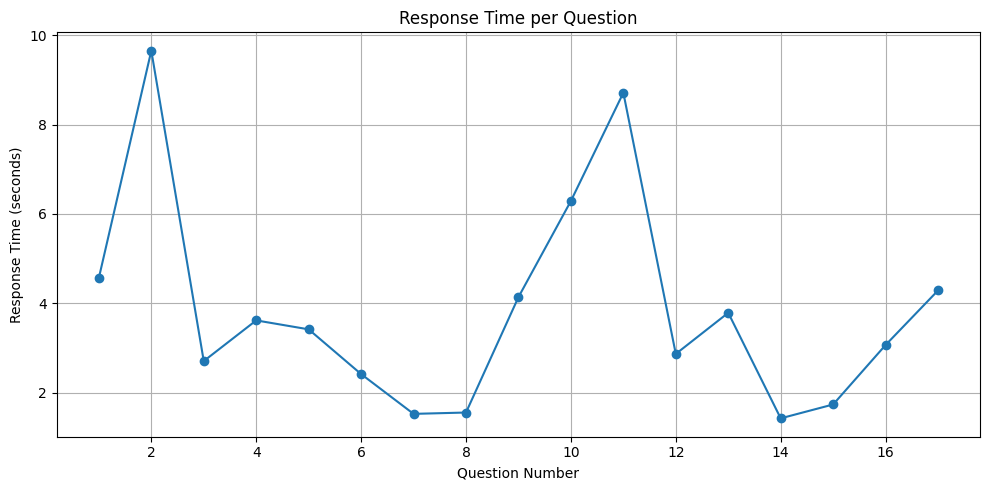

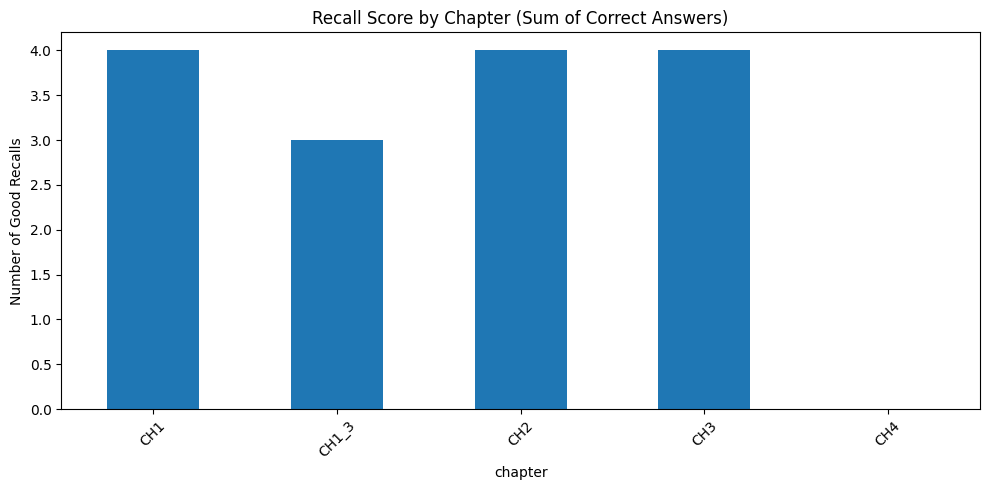

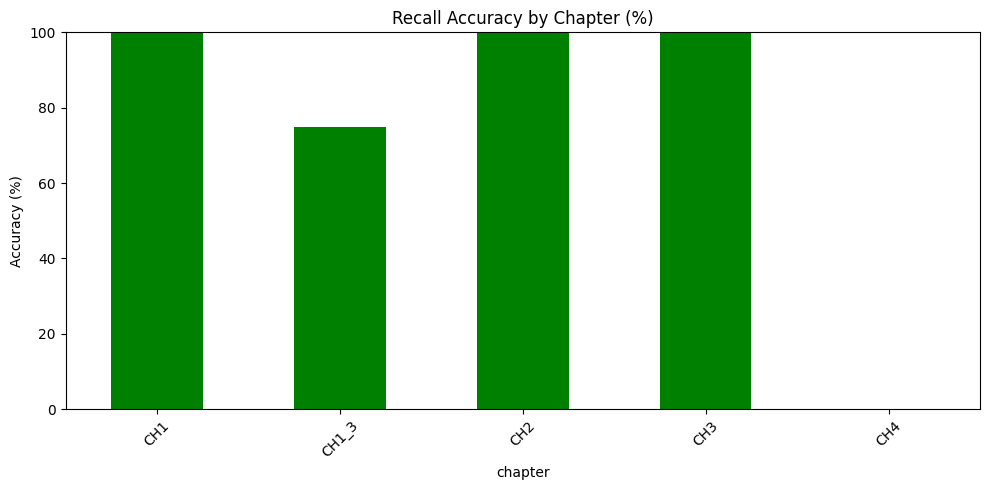

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data (you can expand it as you process more results)
data = [
    {"question_num": 1, "chapter": "CH1", "response_time": 4.57, "recall_score": 1},
    {"question_num": 2, "chapter": "CH1", "response_time": 9.65, "recall_score": 1},
    {"question_num": 3, "chapter": "CH1", "response_time": 2.71, "recall_score": 1},
    {"question_num": 4, "chapter": "CH1", "response_time": 3.62, "recall_score": 1},
    {"question_num": 5, "chapter": "CH1_3", "response_time": 3.42, "recall_score": 1},
    {"question_num": 6, "chapter": "CH1_3", "response_time": 2.42, "recall_score": 0},
    {"question_num": 7, "chapter": "CH1_3", "response_time": 1.53, "recall_score": 1},
    {"question_num": 8, "chapter": "CH1_3", "response_time": 1.56, "recall_score": 1},
    {"question_num": 9, "chapter": "CH2", "response_time": 4.14, "recall_score": 1},
    {"question_num": 10, "chapter": "CH2", "response_time": 6.29, "recall_score": 1},
    {"question_num": 11, "chapter": "CH2", "response_time": 8.71, "recall_score": 1},
    {"question_num": 12, "chapter": "CH2", "response_time": 2.87, "recall_score": 1},
    {"question_num": 13, "chapter": "CH3", "response_time": 3.79, "recall_score": 1},
    {"question_num": 14, "chapter": "CH3", "response_time": 1.43, "recall_score": 1},
    {"question_num": 15, "chapter": "CH3", "response_time": 1.74, "recall_score": 1},
    {"question_num": 16, "chapter": "CH3", "response_time": 3.07, "recall_score": 1},
    {"question_num": 17, "chapter": "CH4", "response_time": 4.29, "recall_score": 0},
]

# Create DataFrame
df = pd.DataFrame(data)

# Show the table
display(df)

# ============================
# 📊 Plot 1: Response Time per Question
# ============================
plt.figure(figsize=(10, 5))
plt.plot(df["question_num"], df["response_time"], marker='o')
plt.title("Response Time per Question")
plt.xlabel("Question Number")
plt.ylabel("Response Time (seconds)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================
# 📊 Plot 2: Recall Score by Chapter (Sum of correct answers)
# ============================
chapter_recall_sum = df.groupby("chapter")["recall_score"].sum()
chapter_question_count = df["chapter"].value_counts().sort_index()
plt.figure(figsize=(10, 5))
chapter_recall_sum.plot(kind="bar")
plt.title("Recall Score by Chapter (Sum of Correct Answers)")
plt.ylabel("Number of Good Recalls")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================
# 📈 Plot 3: Recall Accuracy (%) by Chapter
# ============================
recall_accuracy = (chapter_recall_sum / chapter_question_count) * 100
plt.figure(figsize=(10, 5))
recall_accuracy.plot(kind="bar", color="green")
plt.title("Recall Accuracy by Chapter (%)")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


In [8]:
import requests
import time

# Store the results
results = []

# Map chapter groups manually for now (or automate later)
chapters = (
    ["CH1"] * 4 + ["CH1_3"] * 4 + ["CH2"] * 4 + ["CH3"] * 4 +
    ["CH4"] * 4 + ["CH5"] * 4 + ["CH5_2"] * 4 + ["CH5_3"] * 4 +
    ["CH5_4"] * 4 + ["CH5_5"] * 4 + ["CH6"] * 4 + ["CH7"] * 4 +
    ["CH8.2"] * 4 + ["CH9"] * 4 + ["CH9_3"] * 4
)

for idx, (test, chapter) in enumerate(zip(test_cases_random, chapters), start=1):
    question = test["question"]

    try:
        print(f"\n🧪 Test {idx}")
        print(f"Q: {question}")

        start_time = time.time()
        res = requests.post(API_URL, json={"question": question})
        duration = time.time() - start_time

        res.raise_for_status()
        answer = res.json().get("answer", "[No answer field returned]")

        print(f"🕒 Response Time: {duration:.2f} seconds")
        print(f"💬 Answer: {answer}")

        # Define a simple recall_score metric: 1 if answer looks good, 0 if likely bad
        recall_score = 1
        if "the text does not say" in answer.lower() or "[no answer" in answer.lower():
            recall_score = 0

        results.append({
            "question_num": idx,
            "chapter": chapter,
            "question": question,
            "response_time": round(duration, 2),
            "recall_score": recall_score,
            "answer": answer
        })

    except Exception as e:
        print(f"❌ Error: {e}")
        results.append({
            "question_num": idx,
            "chapter": chapter,
            "question": question,
            "response_time": None,
            "recall_score": 0,
            "answer": f"[ERROR: {e}]"
        })



🧪 Test 1
Q: What are the two ways users can log into MaintStar EAMS v15?
🕒 Response Time: 4.25 seconds
💬 Answer: The two ways users can log into MaintStar EAMS v15 are through the Mobile Work Order and the Work Request and Portal. These are two distinct profiles or environments that users can select upon entering their User ID and passwords. Users can also potentially have an additional profile if they require both a production and a test environment.


🧪 Test 2
Q: How do you close a Work Order?
🕒 Response Time: 8.39 seconds
💬 Answer: To close a Work Order, you can do so either from the MaintStar Public Works desktop software or the mobile application. 

1. If you are using the desktop software: Once the work order has been completed and updated, click on the check mark icon to close it.

2. If you are using the mobile application: Click on the 3 dot menu on the right top corner of the detail screen. A fly out menu will appear giving you a choice to delete or close the work order. Cho

In [9]:
import pandas as pd

# Create DataFrame
df = pd.DataFrame(results)

# Show the table
display(df)


,question_num,chapter,question,response_time,recall_score,answer
0,1,CH1,What are the two ways users can log into Maint...,4.25,1,The two ways users can log into MaintStar EAMS...
1,2,CH1,How do you close a Work Order?,8.39,1,"To close a Work Order, you can do so either fr..."
2,3,CH1,What happens when you click the printer icon o...,3.25,1,When you click the printer icon on a Work Orde...
3,4,CH1,What do you need to do to email a Work Order?,2.73,1,To email a Work Order using the MaintStar Publ...
4,5,CH1_3,What is the main difference between a PM Templ...,5.83,1,A PM Template and a CM Template are both used ...
5,6,CH1_3,Do CM Templates have a frequency or schedule?,3.79,1,"Yes, CM Templates do have both a frequency and..."
6,7,CH1_3,Where are CM Templates created and stored in M...,1.33,1,CM Templates are created and stored in the Wor...
7,8,CH1_3,"When starting from a CM Template, can field va...",3.59,1,"Yes, field values can be modified after the Wo..."
8,9,CH2,What is the purpose of a Preventative Maintena...,3.27,1,A Preventative Maintenance (PM) template conta...
9,10,CH2,What is the difference between fixed and float...,7.68,1,Fixed and floating PM schedules in the MaintSt...


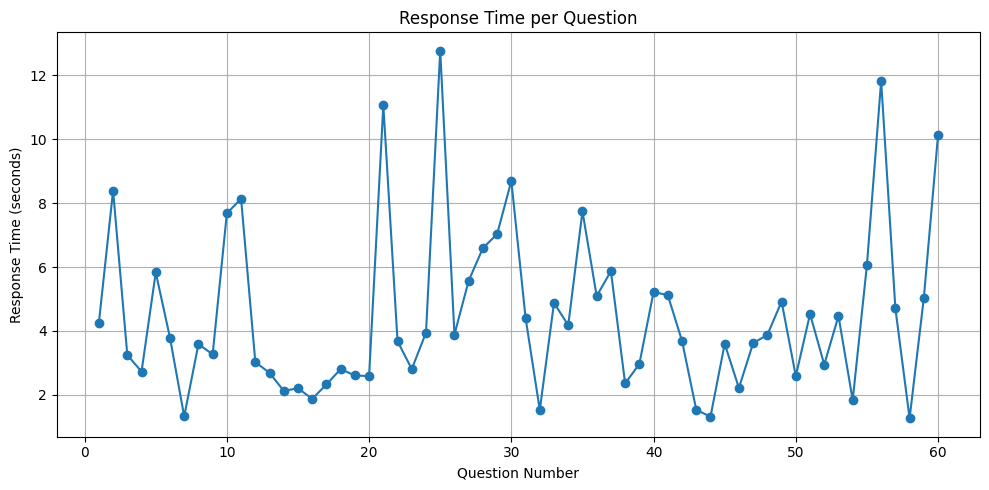

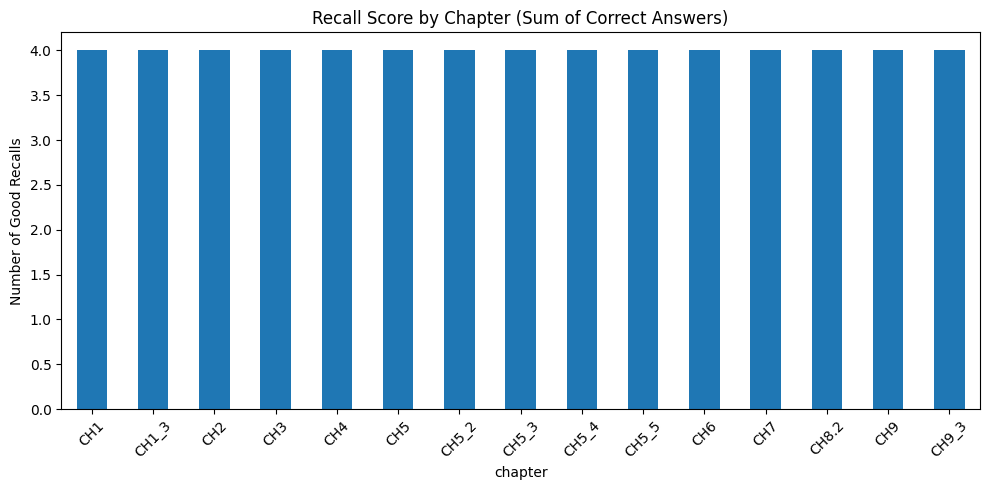

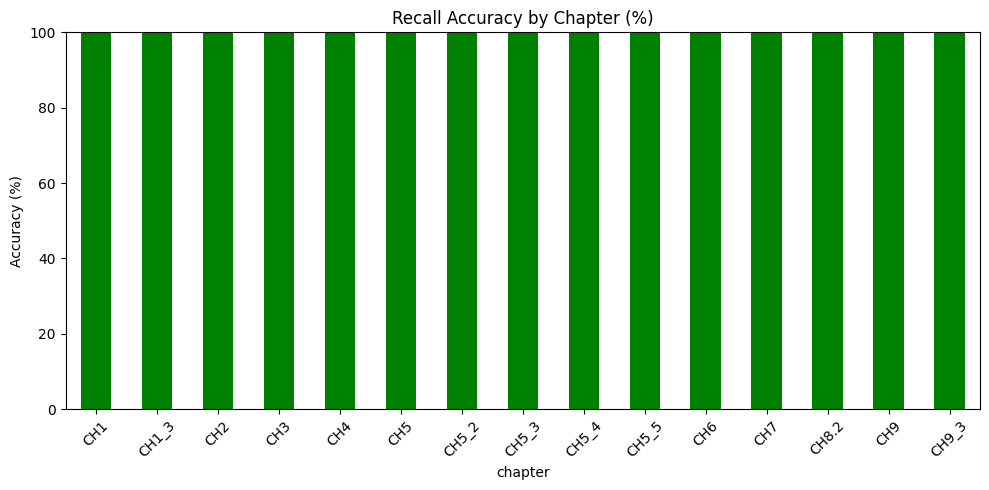

In [10]:
# ============================
# 📊 Plot 1: Response Time per Question
# ============================
plt.figure(figsize=(10, 5))
plt.plot(df["question_num"], df["response_time"], marker='o')
plt.title("Response Time per Question")
plt.xlabel("Question Number")
plt.ylabel("Response Time (seconds)")
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================
# 📊 Plot 2: Recall Score by Chapter (Sum of correct answers)
# ============================
chapter_recall_sum = df.groupby("chapter")["recall_score"].sum()
chapter_question_count = df["chapter"].value_counts().sort_index()
plt.figure(figsize=(10, 5))
chapter_recall_sum.plot(kind="bar")
plt.title("Recall Score by Chapter (Sum of Correct Answers)")
plt.ylabel("Number of Good Recalls")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================
# 📈 Plot 3: Recall Accuracy (%) by Chapter
# ============================
recall_accuracy = (chapter_recall_sum / chapter_question_count) * 100
plt.figure(figsize=(10, 5))
recall_accuracy.plot(kind="bar", color="green")
plt.title("Recall Accuracy by Chapter (%)")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [11]:
# Manually define which questions had incorrect recall
bad_recalls = [21, 22, 23, 31, 38, 41, 42, 43, 44, 46, 58]  # Example

# Set all recall scores to 1 (assume good)
df["recall_score"] = 1

# Set known bad ones to 0
df.loc[df["question_num"].isin(bad_recalls), "recall_score"] = 0


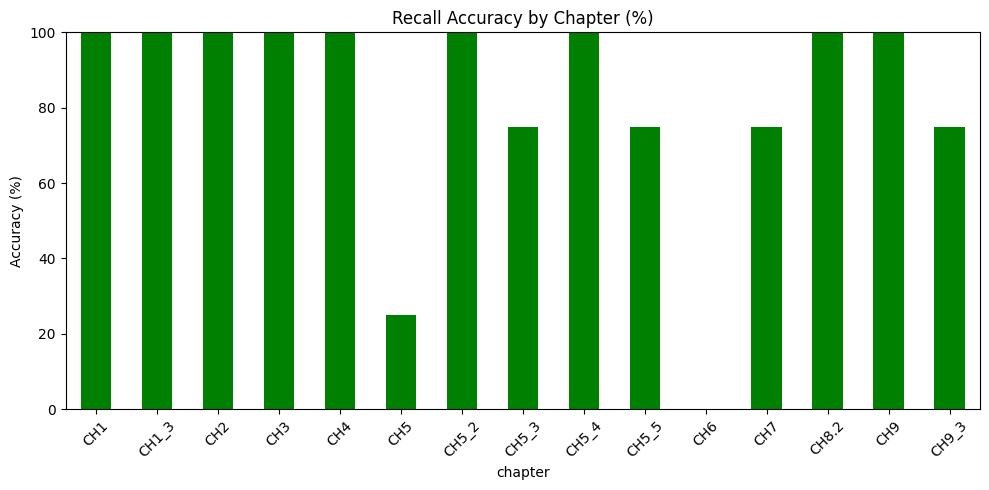

In [12]:
# Grouped recall accuracy by chapter
chapter_recall_sum = df.groupby("chapter")["recall_score"].sum()
chapter_question_count = df["chapter"].value_counts().sort_index()
recall_accuracy = (chapter_recall_sum / chapter_question_count) * 100

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
recall_accuracy.plot(kind="bar", color="green")
plt.title("Recall Accuracy by Chapter (%)")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()
